<a href="https://colab.research.google.com/github/linu-shibu/fraud-detection-imbalance-comparison/blob/main/Credit_Card_Fraud_Detection_Multi_Model_Comparison_Under_Class_Imbalance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Credit Card Fraud Detection: Multi-Model Comparison Under Class Imbalance

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
RANDOM_STATE = 42

In [2]:
credit_card_2020_data = pd.read_csv('/content/credit_card_transactions.csv')

In [3]:
credit_card_2020_data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [4]:
credit_card_2020_data.tail()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,NaN
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,22630.0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,88351.0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,69367.0
1296674,1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,...,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,59870.0


###Exploratory Data Analysis on credit_card_transactions dataset

In [5]:
print(credit_card_2020_data['is_fraud'].isnull().sum())
print(credit_card_2020_data['is_fraud'].unique())

0
[0 1]


In [6]:
credit_card_2020_data = credit_card_2020_data.dropna(subset=['is_fraud'])

In [7]:
# analyse the data
credit_card_2020_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [8]:
# checking no. of missing values in each col
credit_card_2020_data.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [9]:
# data distribution of valid vs fraudulent transaction
credit_card_2020_data['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


Dataset is imbalanced with legit to fraud transaction ratio as
172:1 . This is expected and resemblant of real word datasets.


In [10]:
credit_card_2020_data['datetime'] = pd.to_datetime(credit_card_2020_data['trans_date_trans_time'])
credit_card_2020_data['hour'] = credit_card_2020_data['datetime'].dt.hour
credit_card_2020_data['day_of_week'] = credit_card_2020_data['datetime'].dt.dayofweek
credit_card_2020_data['is_late_night'] = credit_card_2020_data['hour'].apply(lambda x: 1 if x >= 23 or x <= 4 else 0)

In [11]:
credit_card_2020_data.groupby('is_fraud')[['hour', 'day_of_week', 'is_late_night']].mean()

,hour,day_of_week,is_late_night
is_fraud,,,
0,12.797679,3.070312,0.213538
1,14.037836,3.120703,0.596456


## Dealing with Data Imbalance using Undersampling before training models


In [12]:
legit_transactions = credit_card_2020_data[credit_card_2020_data.is_fraud == 0]
fraudulent_transactions = credit_card_2020_data[credit_card_2020_data.is_fraud == 1]

In [13]:
print(legit_transactions.shape)
print(fraudulent_transactions.shape)

(1289169, 28)
(7506, 28)


In [14]:
legit_transactions.amt.describe()

,amt
count,1.289169e+06
mean,6.766711e+01
std,1.540080e+02
min,1.000000e+00
25%,9.610000e+00
50%,4.728000e+01
75%,8.254000e+01
max,2.894890e+04


In [15]:
fraudulent_transactions.amt.describe()

,amt
count,7506.000000
mean,531.320092
std,390.560070
min,1.060000
25%,245.662500
50%,396.505000
75%,900.875000
max,1376.040000


In [16]:
credit_card_2020_data.groupby('is_fraud').mean(numeric_only=True)


,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,merch_zipcode,hour,day_of_week,is_late_night
is_fraud,,,,,,,,,,,,,,
0,648473.169029,4.172901e+17,67.667110,48805.107481,38.536888,-90.228142,88775.228137,1.349249e+09,38.536659,-90.228274,46831.647860,12.797679,3.070312,0.213538
1,624949.724354,4.003577e+17,531.320092,48038.714229,38.663609,-89.916041,97276.763256,1.348389e+09,38.653901,-89.915808,45812.125884,14.037836,3.120703,0.596456


Undersample legit transactions set, ie, randomly take around 7000 rows of legit transaction so the ratio of legit:fraud becomes 1:1.



In [17]:
X_full = credit_card_2020_data.drop(columns=['Unnamed: 0', 'cc_num', 'trans_date_trans_time', 'is_fraud'])
Y_full = credit_card_2020_data['is_fraud']

X_train_full, X_test, Y_train_full, Y_test = train_test_split(
    X_full, Y_full, test_size=0.2, stratify=Y_full, random_state=RANDOM_STATE
)

In [18]:
train_data = pd.concat([X_train_full, Y_train_full], axis=1)
legit_train = train_data[train_data.is_fraud == 0]
fraud_train = train_data[train_data.is_fraud == 1]

legit_train_sample = legit_train.sample(n=len(fraud_train), random_state=RANDOM_STATE)
train_undersampled = pd.concat([legit_train_sample, fraud_train], axis=0)

X_train = train_undersampled.drop(columns=['is_fraud'])
Y_train = train_undersampled['is_fraud']

## Feature engineering

We will convert possible columns to features that are useful to models to understand data and drop any useless ones after this process.


In [19]:
columns_to_drop = ['first', 'last', 'street', 'city', 'trans_num', 'datetime']

X_train = X_train.drop(columns=columns_to_drop, errors='ignore')
X_test = X_test.drop(columns=columns_to_drop, errors='ignore')

Target encoding allows us to convert numerical catogorical data to numerical values that represent the probability of that column belonging to a specific class, which is useful to model rather than plain string.

For example, in case of "merchant" column, target encoding converts each merchant column to a numerical value indication how likely that merchant transaction is a fraud transaction.

In [20]:
def add_target_encoding(X_train, X_test, y_train, columns, global_mean=None):
    """
    Target-encode categorical columns using training-set fraud rates only.

    Parameters
    ----------
    X_train, X_test : DataFrame
        Feature sets to encode. Not modified in place.
    y_train : Series
        Training labels, used to compute per-category fraud rates.
    columns : list of str
        Categorical columns to encode and drop.
    global_mean : float, optional
        Fallback rate for categories unseen in training. Defaults to
        the overall training fraud rate if not provided.

    Returns
    -------
    X_train, X_test : DataFrame
        Copies with each column in `columns` replaced by
        `{column}_encoded` and the original column dropped.
    """
    if global_mean is None:
        global_mean = y_train.mean()

    X_train = X_train.copy()
    X_test = X_test.copy()

    for col in columns:
        category_means = y_train.groupby(X_train[col], observed=False).mean()
        X_train[f'{col}_encoded'] = X_train[col].map(category_means).fillna(global_mean)
        X_test[f'{col}_encoded'] = X_test[col].map(category_means).fillna(global_mean)
        X_train = X_train.drop(columns=[col])
        X_test = X_test.drop(columns=[col])

    return X_train, X_test

In [21]:
categorical_columns = ['merchant', 'category', 'gender', 'state', 'job']
X_train, X_test = add_target_encoding(X_train, X_test, Y_train, categorical_columns)

Deriving transaction time (current time) and date of birth as age gives models a better and more understandable feature to learn from.

In [22]:
train_years = pd.to_datetime(X_train['unix_time'], unit='s').dt.year
train_birth_years = pd.to_datetime(X_train['dob']).dt.year

test_years = pd.to_datetime(X_test['unix_time'], unit='s').dt.year
test_birth_years = pd.to_datetime(X_test['dob']).dt.year

X_train['age'] = train_years - train_birth_years
X_test['age'] = test_years - test_birth_years

X_train = X_train.drop(columns=['dob', 'unix_time'])
X_test = X_test.drop(columns=['dob', 'unix_time'])

In [23]:
print(X_full.shape, X_train.shape, X_test.shape)
print(Y_full.shape, Y_train.shape, Y_test.shape)

(1296675, 24) (12010, 17) (259335, 17)
(1296675,) (12010,) (259335,)


In [24]:
X_train.head()

,amt,zip,lat,long,city_pop,merch_lat,merch_long,merch_zipcode,hour,day_of_week,is_late_night,merchant_encoded,category_encoded,gender_encoded,state_encoded,job_encoded,age
524010,5.29,68031,41.6414,-96.5232,1745,40.924250,-97.108503,68434.0,20,1,0,0.307692,0.336898,0.474736,0.569721,0.357143,39
655631,21.09,15377,39.9914,-80.4408,724,40.346460,-80.220465,15057.0,12,6,0,0.714286,0.720588,0.474736,0.488372,0.360000,17
663694,93.26,52535,40.8626,-91.9534,888,40.620401,-91.750883,52626.0,0,3,1,0.696970,0.700307,0.474736,0.462500,0.000000,24
725896,133.03,58769,48.3396,-102.2400,229,48.121431,-101.373506,58701.0,2,2,1,0.538462,0.548178,0.527450,0.408333,0.407407,29
1239498,67.18,70466,30.5668,-90.4820,8512,30.341336,-89.896494,70445.0,4,0,1,0.300000,0.320242,0.527450,0.441341,0.321429,62


In [25]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

merch_zipcode    1809
dtype: int64


In [26]:
# Fill missing merchant ZIP codes with -1 in both train and test sets
X_train['merch_zipcode'] = X_train['merch_zipcode'].fillna(-1)
X_test['merch_zipcode'] = X_test['merch_zipcode'].fillna(-1)

In [27]:
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Series([], dtype: int64)


In [28]:
print(X_train.columns)

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long',
       'merch_zipcode', 'hour', 'day_of_week', 'is_late_night',
       'merchant_encoded', 'category_encoded', 'gender_encoded',
       'state_encoded', 'job_encoded', 'age'],
      dtype='object')


In [29]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

def evaluate_model(model, X, y_true, label=""):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    print(f"--- {label} ---")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC   : {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC    : {average_precision_score(y_true, y_proba):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    return {
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

results = []

def run_and_evaluate(name, model, X_train, Y_train, X_test, Y_test):
    start = time.time()
    model.fit(X_train, Y_train)
    fit_time = time.time() - start

    start = time.time()
    metrics = evaluate_model(model, X_test, Y_test, label=f"{name} - Test")
    predict_time = time.time() - start

    metrics["model"] = name
    metrics["fit_time_sec"] = fit_time
    metrics["predict_time_sec"] = predict_time
    results.append(metrics)
    return model

Models


In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Create a pipeline that scales the data first, then passes it to the model
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=500) # Boosted steps + scaling = perfect convergence
)

# Train the model safely without any warnings!
model.fit(X_train, Y_train)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=500))])

In [31]:
train_metrics = evaluate_model(model, X_train, Y_train, label="Logistic Regression - Train")
test_metrics = evaluate_model(model, X_test, Y_test, label="Logistic Regression - Test")

--- Logistic Regression - Train ---
Precision : 0.8836
Recall    : 0.8368
F1        : 0.8596
ROC-AUC   : 0.9399
PR-AUC    : 0.9417
Confusion Matrix:
[[5343  662]
 [ 980 5025]]

--- Logistic Regression - Test ---
Precision : 0.0352
Recall    : 0.8108
F1        : 0.0675
ROC-AUC   : 0.9141
PR-AUC    : 0.2235
Confusion Matrix:
[[224471  33363]
 [   284   1217]]



In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import time

In [33]:
lr_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, random_state=RANDOM_STATE))
lr_model = run_and_evaluate("Logistic Regression", lr_model, X_train, Y_train, X_test, Y_test)

--- Logistic Regression - Test ---
Precision : 0.0352
Recall    : 0.8108
F1        : 0.0675
ROC-AUC   : 0.9141
PR-AUC    : 0.2235
Confusion Matrix:
[[224471  33363]
 [   284   1217]]



In [34]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model = run_and_evaluate("Random Forest", rf_model, X_train, Y_train, X_test, Y_test)

--- Random Forest - Test ---
Precision : 0.1275
Recall    : 0.9500
F1        : 0.2248
ROC-AUC   : 0.9928
PR-AUC    : 0.8036
Confusion Matrix:
[[248076   9758]
 [    75   1426]]



In [35]:
xgb_model = XGBClassifier(
    n_estimators=200, random_state=RANDOM_STATE,
    eval_metric='logloss', n_jobs=-1
)
xgb_model = run_and_evaluate("XGBoost", xgb_model, X_train, Y_train, X_test, Y_test)

--- XGBoost - Test ---
Precision : 0.1783
Recall    : 0.9793
F1        : 0.3016
ROC-AUC   : 0.9975
PR-AUC    : 0.8395
Confusion Matrix:
[[251058   6776]
 [    31   1470]]



In [36]:
X_train_svm = X_train.sample(n=5000, random_state=RANDOM_STATE)
Y_train_svm = Y_train.loc[X_train_svm.index]

svm_model = make_pipeline(StandardScaler(), SVC(probability=True, random_state=RANDOM_STATE))
svm_model = run_and_evaluate("SVM", svm_model, X_train_svm, Y_train_svm, X_test, Y_test)

--- SVM - Test ---
Precision : 0.0471
Recall    : 0.8461
F1        : 0.0893
ROC-AUC   : 0.9355
PR-AUC    : 0.3379
Confusion Matrix:
[[232157  25677]
 [   231   1270]]



In [37]:
mlp_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=RANDOM_STATE)
)
mlp_model = run_and_evaluate("MLP", mlp_model, X_train, Y_train, X_test, Y_test)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


--- MLP - Test ---
Precision : 0.0593
Recall    : 0.9027
F1        : 0.1113
ROC-AUC   : 0.9700
PR-AUC    : 0.5156
Confusion Matrix:
[[236340  21494]
 [   146   1355]]



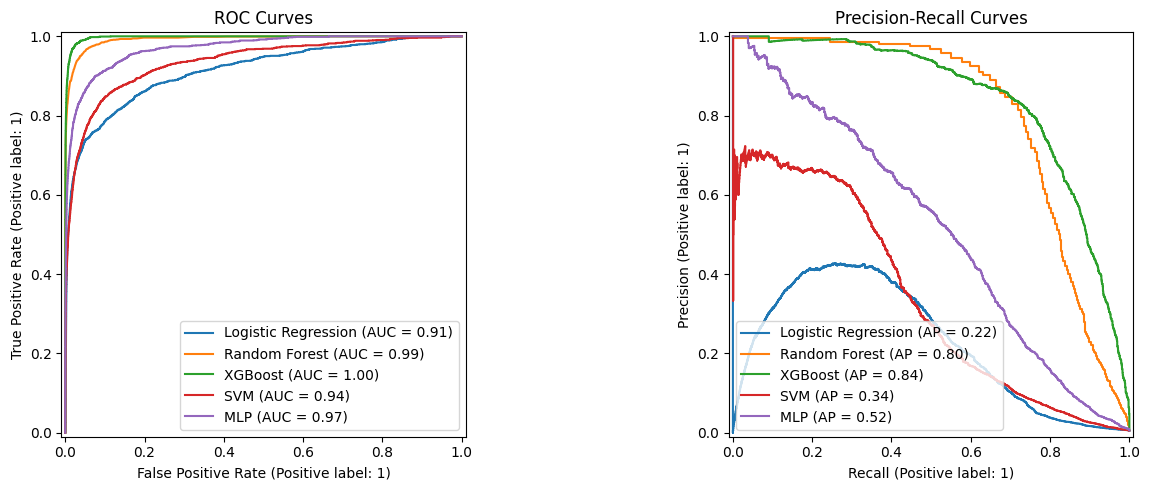

In [38]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model, X_te in [
    ("Logistic Regression", lr_model, X_test), ("Random Forest", rf_model, X_test),
    ("XGBoost", xgb_model, X_test), ("SVM", svm_model, X_test), ("MLP", mlp_model, X_test)
]:
    RocCurveDisplay.from_estimator(model, X_te, Y_test, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_te, Y_test, ax=axes[1], name=name)

axes[0].set_title("ROC Curves")
axes[1].set_title("Precision-Recall Curves")
plt.tight_layout()
plt.show()

## Comparing XGBoost performance when using different Imbalance Correction methods

Since XGBoost performs the best among all compared models, we will compare the performance of XGBoost when using different imabalance correction methods, namely, undersampling(already done), weighted class and SMOTE

In [39]:
from imblearn.over_sampling import SMOTE

In [40]:
# Re-run the same split (same random_state -> identical split, just fresh/unmutated copies)
X_train_full_raw, X_test_raw, Y_train_full, Y_test = train_test_split(
    X_full, Y_full, test_size=0.2, stratify=Y_full, random_state=RANDOM_STATE
)

X_train_full_fe = X_train_full_raw.drop(columns=columns_to_drop, errors='ignore')
X_test_imb = X_test_raw.drop(columns=columns_to_drop, errors='ignore')

X_train_full_fe, X_test_imb = add_target_encoding(X_train_full_fe, X_test_imb, Y_train_full, categorical_columns)

train_years_full = pd.to_datetime(X_train_full_fe['unix_time'], unit='s').dt.year
train_birth_years_full = pd.to_datetime(X_train_full_fe['dob']).dt.year
X_train_full_fe['age'] = train_years_full - train_birth_years_full
X_train_full_fe = X_train_full_fe.drop(columns=['dob', 'unix_time'])
X_train_full_fe['merch_zipcode'] = X_train_full_fe['merch_zipcode'].fillna(-1)

test_years_full = pd.to_datetime(X_test_imb['unix_time'], unit='s').dt.year
test_birth_years_full = pd.to_datetime(X_test_imb['dob']).dt.year
X_test_imb['age'] = test_years_full - test_birth_years_full
X_test_imb = X_test_imb.drop(columns=['dob', 'unix_time'])
X_test_imb['merch_zipcode'] = X_test_imb['merch_zipcode'].fillna(-1)

In [41]:
scale_pos_weight = (Y_train_full == 0).sum() / (Y_train_full == 1).sum()

xgb_weighted = XGBClassifier(
    n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss',
    n_jobs=-1, scale_pos_weight=scale_pos_weight
)
xgb_weighted = run_and_evaluate("XGBoost - Class Weighted", xgb_weighted, X_train_full_fe, Y_train_full, X_test_imb, Y_test)

--- XGBoost - Class Weighted - Test ---
Precision : 0.6787
Recall    : 0.9107
F1        : 0.7778
ROC-AUC   : 0.9976
PR-AUC    : 0.9276
Confusion Matrix:
[[257187    647]
 [   134   1367]]



In [42]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, Y_train_smote = smote.fit_resample(X_train_full_fe, Y_train_full)

xgb_smote = XGBClassifier(n_estimators=200, random_state=RANDOM_STATE, eval_metric='logloss', n_jobs=-1)
xgb_smote = run_and_evaluate("XGBoost - SMOTE", xgb_smote, X_train_smote, Y_train_smote, X_test_imb, Y_test)

--- XGBoost - SMOTE - Test ---
Precision : 0.8555
Recall    : 0.8561
F1        : 0.8558
ROC-AUC   : 0.9950
PR-AUC    : 0.9115
Confusion Matrix:
[[257617    217]
 [   216   1285]]



In [43]:
undersampling_entry = next(r for r in results if r["model"] == "XGBoost").copy()
undersampling_entry["model"] = "XGBoost - Undersampling"
results.append(undersampling_entry)

In [44]:
imbalance_results_df = pd.DataFrame(results).set_index("model")
imbalance_results_df = imbalance_results_df.loc[
    ["XGBoost - Undersampling", "XGBoost - Class Weighted", "XGBoost - SMOTE"],
    ["precision", "recall", "f1", "roc_auc", "pr_auc", "fit_time_sec"]
]
imbalance_results_df.sort_values("pr_auc", ascending=False)

,precision,recall,f1,roc_auc,pr_auc,fit_time_sec
model,,,,,,
XGBoost - Class Weighted,0.678749,0.910726,0.777809,0.997564,0.927646,29.890694
XGBoost - SMOTE,0.855526,0.856096,0.855811,0.994957,0.911530,56.020080
XGBoost - Undersampling,0.178268,0.979347,0.301631,0.997488,0.839452,0.647012


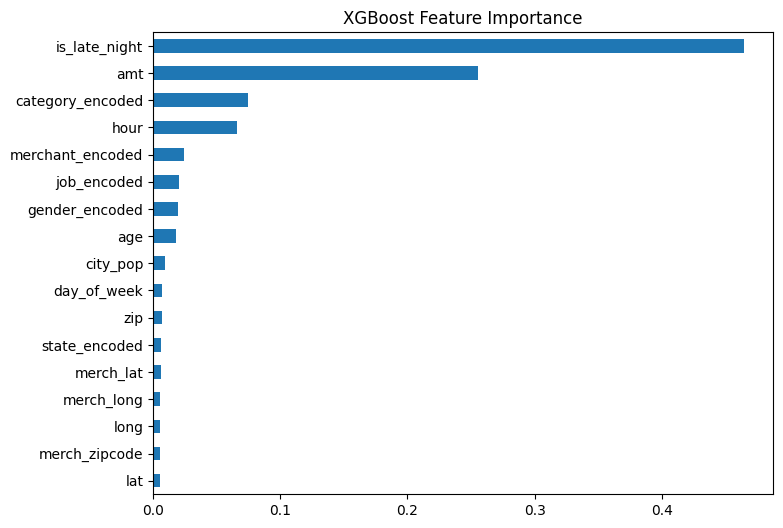

In [45]:
import matplotlib.pyplot as plt
importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns).sort_values()
importances.plot(kind='barh', figsize=(8,6), title='XGBoost Feature Importance')
plt.show()

## Conclusion:
Summing everything up, we worked with a dataset of credit card transactions containing details like transaction time, amount, merchant, and cardholder demographics. After loading the data, we performed exploratory data analysis to understand which features were useful, which needed to be dropped (e.g. names, addresses), and which could be derived into more useful signals (e.g. age, time-of-day). This analysis confirmed the dataset was heavily imbalanced (172:1 legit-to-fraud), consistent with real-world where number of legit trnasactions far exceed fraud transactions in count.

A key design decision was splitting the data into train and test sets before applying any imbalance correction, so the test set retained the real-world class ratio. Evaluating on an artificially balanced test set would have produced misleadingly optimistic numbers; keeping it realistic meant our metrics actually reflect production performance.

We trained five classifiers - namely Logistic Regression, Random Forest, XGBoost, SVM, and MLP, using training data undersampled to a 1:1 ratio. XGBoost clearly outperformed the others across precision, recall, and PR-AUC, so we selected it for further evaluation. We then compared three imbalance-handling strategies for XGBoost, specifically undersampling, class weighting, and SMOTE on the full imbalanced training set (except undersampling, by definition). Class weighting achieved the best recall and PR-AUC (catching the most fraud), while SMOTE achieved a better precision/recall balance (highest F1) with fewer false alarms. The right choice between them depends on the relative cost of a missed fraud versus a false positive in a given business context.

Finally, feature importance analysis showed is_late_night and transaction amt were by far the most predictive features, ahead of any of the target-encoded categorical fields.